# Final Proyect Supervised Learning

## Caso 1. Predicción de enfermedades cardiovasculares

A new system for the early detection of cardiovascular pathologies has been developed. However, performing the test and making the diagnosis is a costly and slow process. Therefore, your company asks you to develop an algorithm to filter out cases that do not require such an exhaustive detection process.

- Select an appropriate classification algorithm for this problem (being able to detect patients with or without cardiovascular pathology). Justify your choice.

- Show the results of the algorithm, attempting to meet the client’s specific requirements:
   - Minimize false negatives (patients with the pathology incorrectly classified as healthy).

   - Maintain an acceptable level of false positives (healthy patients incorrectly classified as having the disease).

- Investigate other possible algorithms beyond those studied in class that may be suitable for this problem. Select one and compare its performance with the initial algorithm.


### Loading and overview of the dataset

We use the dataset [Heart Disease](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset/data).

- This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. **The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease**.

- Information about the attributes (14 used in total):
    - age: age in years
    - sex: sex (1 = male; 0 = female)
    - cp: chest pain type:
        - Value 0: typical angina
        - Value 1: atypical angina
        - Value 2: non-anginal pain
        - Value 3: asymptomatic
    - trestbps: resting blood pressure in mm Hg on admission to the hospital
    - chol: serum cholestoral in mg/dl
    - fbs: fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    - restecg: resting electrocardiographic results:
        - Value 0: normal
        - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
        - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
    - thalach: maximum heart rate achieved
    - exang: exercise induced angina (1 = yes; 0 = no)
    - oldpeak: ST depression induced by exercise relative to rest
    - slope: the slope of the peak exercise ST segment:
        - Value 0: upsloping (normal)
        - Value 1: flat (stable)
        - Value 2: downsloping (unhealthy)
    - ca: number of major vessels (0-3) colored by flourosopy
    - thal:
        - Value 1: normal
        - Value 2: fixed defect
        - Value 3: reversible defect
    - target: 0 = no disease, 1 = disease
> The names and social security numbers of the patients were removed from the database, replaced with dummy values.



In [2]:
import pandas as pd

df = pd.read_csv('datasets/heart.csv')
print("Dataset size:", df.shape)
df.head()

Dataset size: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

### Data Cleaning

In [4]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


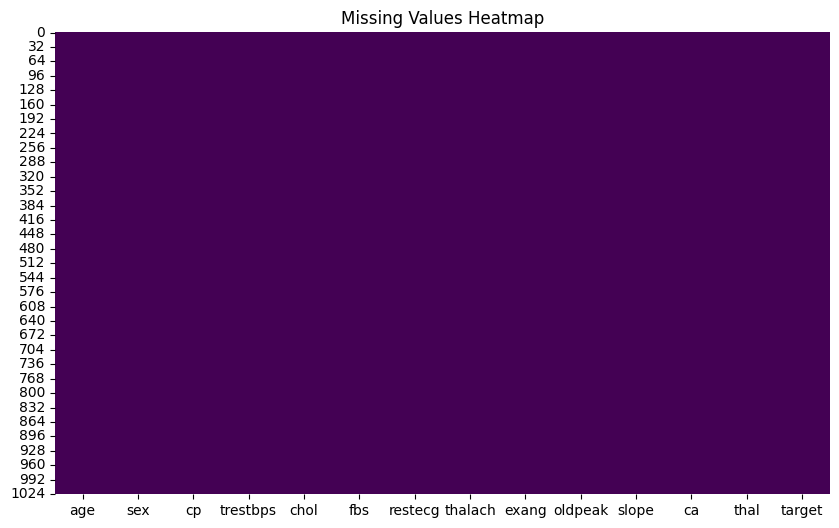

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

- There are no missing values in the dataset, so data imputation or removal of rows/columns with missing values is not necessary.

In [6]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates(ignore_index=True) # it keeps the first occurrence by default
print("Dataset size after removing duplicates:", df.shape)

Number of duplicate rows: 723
Dataset size after removing duplicates: (302, 14)


> There is 723 duplicated rows in the dataset. After removing them, we have 302 unique rows, which is a very small dataset for training a classification model.
 
> This will limit the complexity of the models we can use and may lead to overfitting. We will need to be careful with model selection and validation to ensure we get reliable results.

We check again the source of our data and we found that the [original dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) contains 303 unique rows. We will stick for the exercise to the 302 unique rows we have after removing duplicates, but we will check if there are more incosistencies.
> The missing row from the original dataset was a duplicate, so no data is lost.

#### Check unique values for categorical features

In [7]:
print(df['thal'].value_counts())
print(df['slope'].value_counts())
print(df['target'].value_counts())
print(df['ca'].value_counts())
print(df['sex'].value_counts())
print(df['cp'].value_counts())
print(df['fbs'].value_counts())
print(df['restecg'].value_counts())
print(df['exang'].value_counts())

thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64
slope
2    141
1    140
0     21
Name: count, dtype: int64
target
1    164
0    138
Name: count, dtype: int64
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64
sex
1    206
0     96
Name: count, dtype: int64
cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64
fbs
0    257
1     45
Name: count, dtype: int64
restecg
1    151
0    147
2      4
Name: count, dtype: int64
exang
0    203
1     99
Name: count, dtype: int64


ca and thal features seems to have some inconsistent values (4 and 0 respectively), we will remove those rows.

In [8]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)]
print("Dataset size after removing inconsistent values:", df.shape)

Dataset size after removing inconsistent values: (296, 14)


Let's check outliers in numerical features using boxplots.

Feature: age
Outliers: []
Total outliers: 0 (0.00%)
count    296.000000
mean      54.523649
std        9.059471
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64 



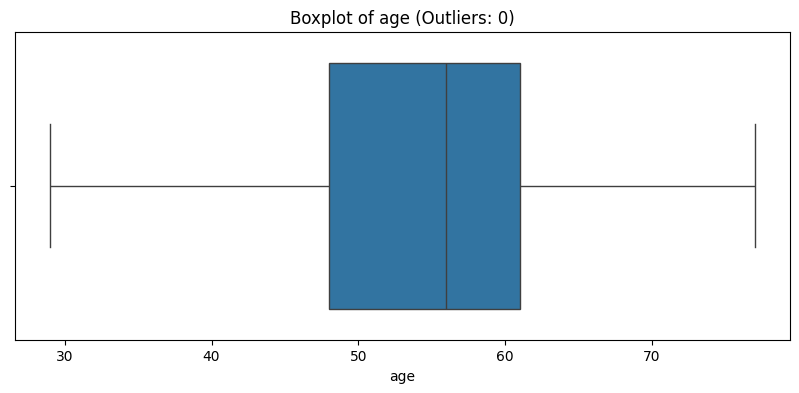

Feature: trestbps
Outliers: [180 178 174 180 192 200 172 180 178]
Total outliers: 9 (3.04%)
count    296.00000
mean     131.60473
std       17.72662
min       94.00000
25%      120.00000
50%      130.00000
75%      140.00000
max      200.00000
Name: trestbps, dtype: float64 



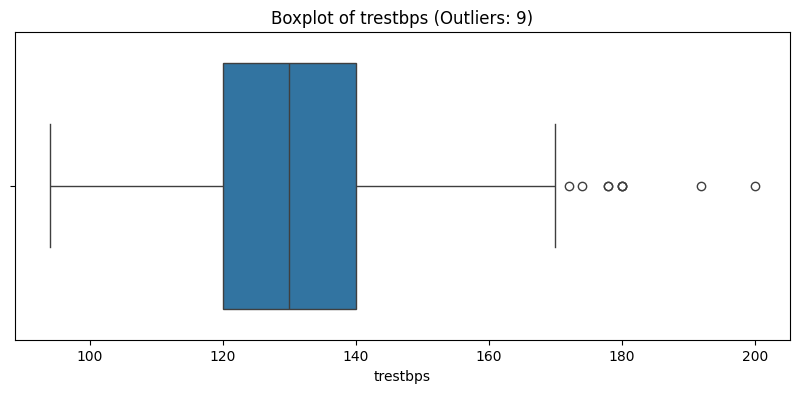

Feature: chol
Outliers: [417 564 409 394 407]
Total outliers: 5 (1.69%)
count    296.000000
mean     247.155405
std       51.977011
min      126.000000
25%      211.000000
50%      242.500000
75%      275.250000
max      564.000000
Name: chol, dtype: float64 



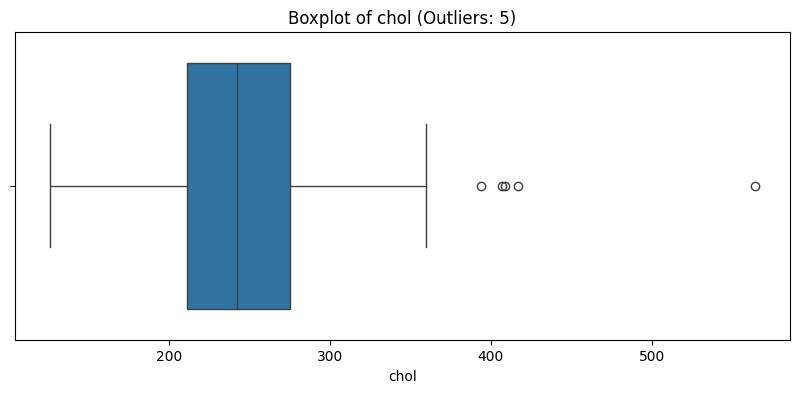

Feature: thalach
Outliers: [71]
Total outliers: 1 (0.34%)
count    296.000000
mean     149.560811
std       22.970792
min       71.000000
25%      133.000000
50%      152.500000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64 



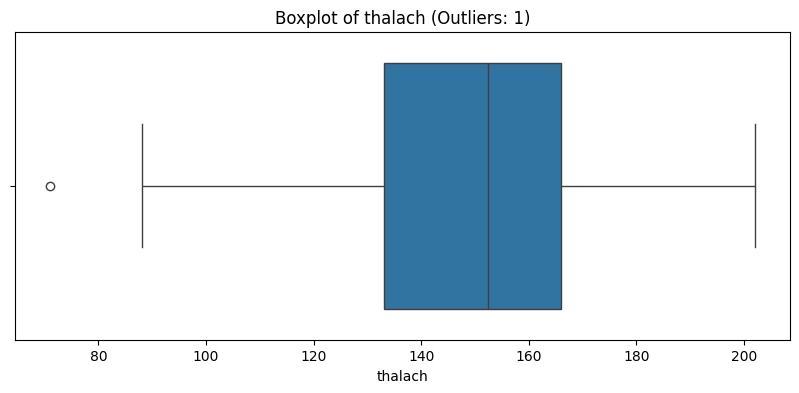

Feature: oldpeak
Outliers: [4.4 4.2 5.6 6.2 4.2]
Total outliers: 5 (1.69%)
count    296.000000
mean       1.059122
std        1.166474
min        0.000000
25%        0.000000
50%        0.800000
75%        1.650000
max        6.200000
Name: oldpeak, dtype: float64 



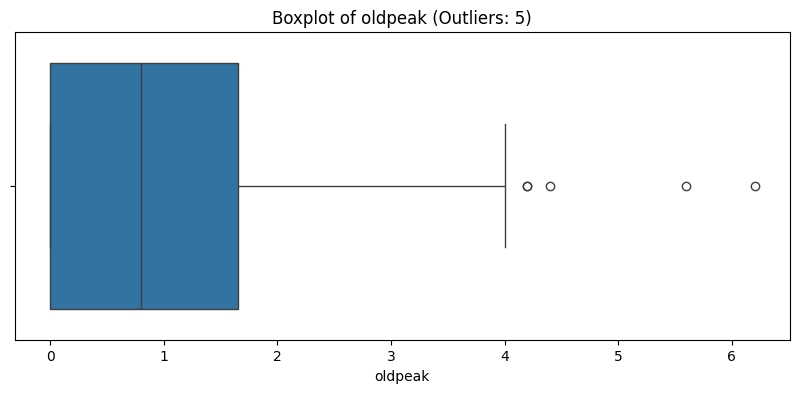

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_outliers(data, features):
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
        perc_outliers = outliers.shape[0] / data.shape[0] * 100
        
        print(f'Feature: {feature}')
        print(f'Outliers: {outliers[feature].values}')
        print(f'Total outliers: {outliers.shape[0]} ({perc_outliers:.2f}%)')
        print(data[feature].describe(), "\n")
        
        # Visualization
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=data[feature])
        plt.title(f'Boxplot of {feature} (Outliers: {outliers.shape[0]})')
        plt.show()

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
visualize_outliers(df, numerical_features)

In [10]:
# Q1 = df[numerical_features].quantile(0.25)
# Q3 = df[numerical_features].quantile(0.75)
# IQR = Q3 - Q1
# df = df[~((df[numerical_features] < (Q1 - 1.5 * IQR)) | (df[numerical_features] > (Q3 + 1.5 * IQR))).any(axis=1)]
# print("Dataset size after removing outliers:", df.shape)

The outliers detected could be valid data points, so we will not remove them for now.

> They should be validated with domain experts before deciding to remove them.

> Removing them, given the small size of the dataset, leads to a significant reduction in data (from 302 to 277 rows) and the models performance drops significantly.

Now that our dataset is clean, we can start exploring it and training models.

### Data Analysis

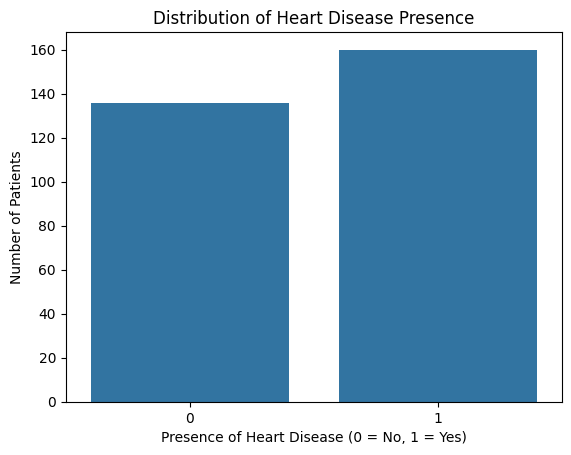

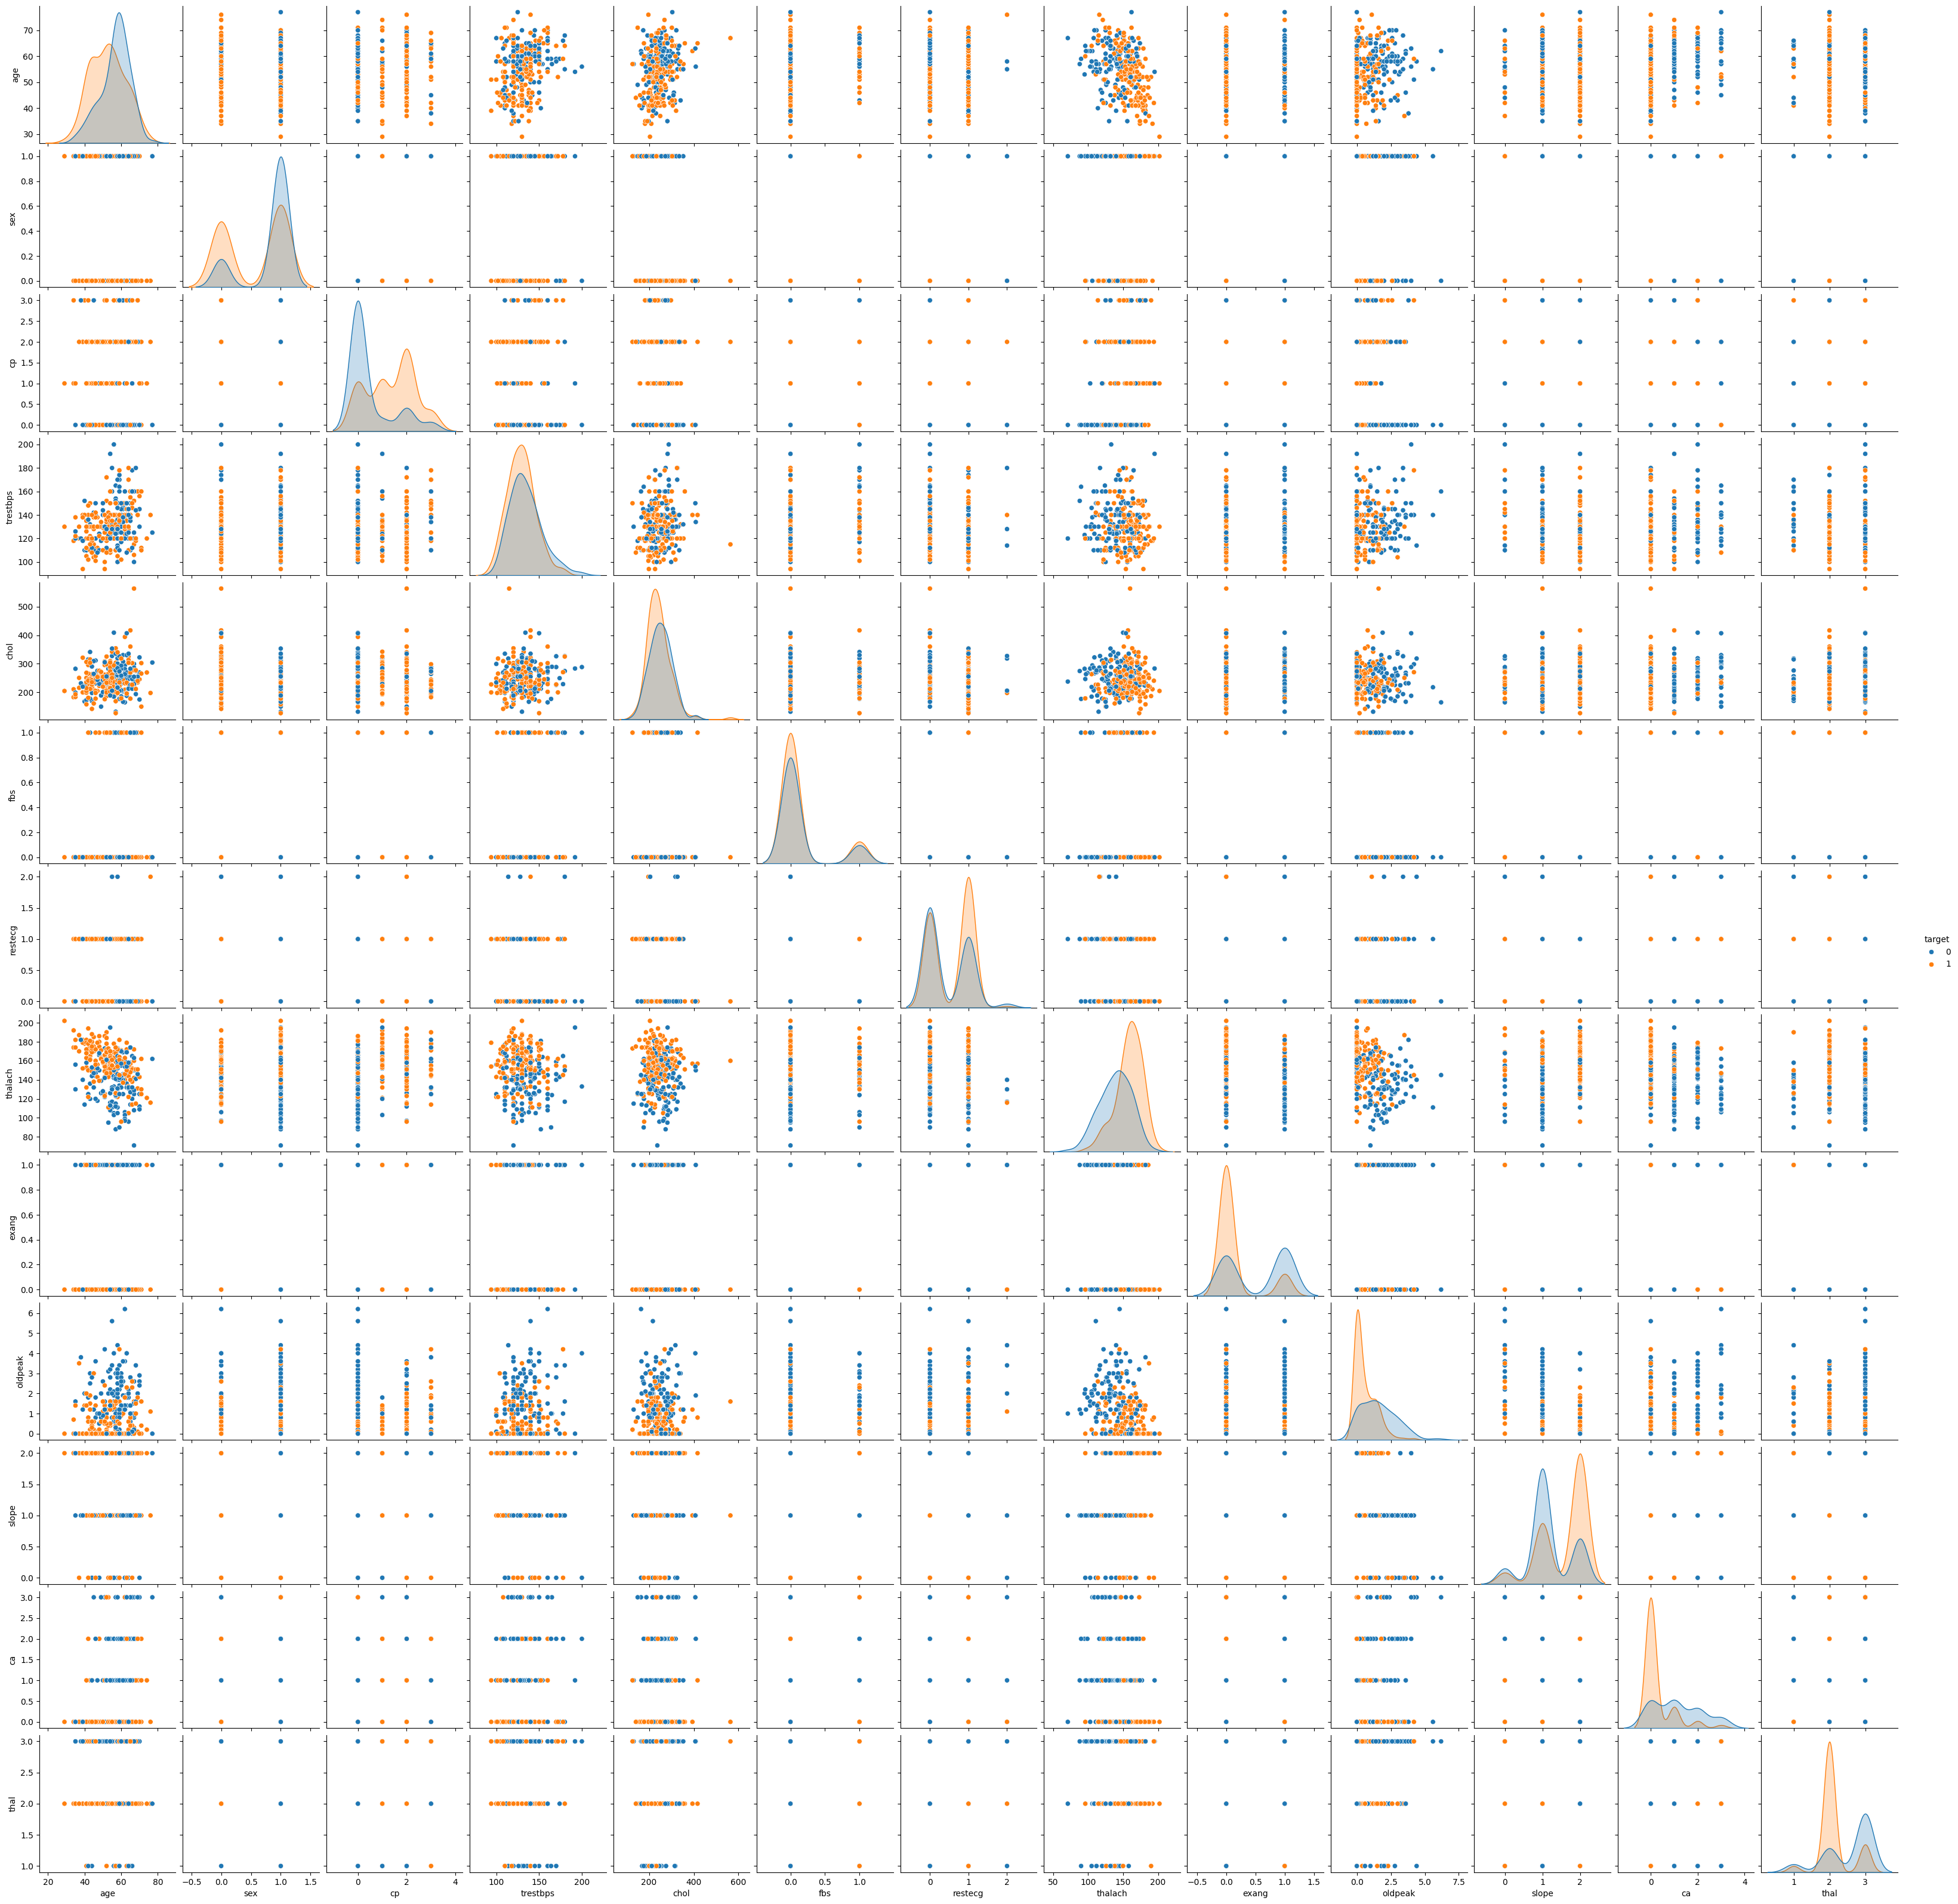

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease Presence')
xlabel = 'Presence of Heart Disease (0 = No, 1 = Yes)'
ylabel = 'Number of Patients'
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

sns.pairplot(df, hue='target')
plt.show()

Of the selected 14 features, the following are categorical variables:
- sex (binary)
- cp (4 categories)
- fbs (binary)
- restecg (3 categories)
- exang (binary)
- slope (3 categories)
- ca (4 categories)
- thal (3 categories)
- target (binary)

The remaining features are numerical:
- age (units: years)
- trestbps (units: mm Hg)
- chol (units: mg/dl)
- thalach (units: beats per minute)
- oldpeak (units: ST depression)

> The average age of patients is 54 years, with a standard deviation of 9.1 years.

> The data is balanced, with approximately half of patients having heart disease and half not.

> But it shows a higher amount of male patients (approximately 70%) compared to female patients (approximately 30%), we will focus on this aspect in our analysis next.

> The numerical (continuous) features have different scales, so we will need to standardize or normalize them before training models that are sensitive to feature scaling (e.g., SVM, KNN, etc.).

> The categorical features will need to be encoded appropriately (e.g., one-hot encoding, label encoding, etc.) before training models.

In [12]:
num_males = len(df[df['sex'] == 1])
num_females = len(df[df['sex'] == 0])
print(f'Number of male patients: {num_males}')
print(f'Number of female patients: {num_females}')
mask_male_with_disease = (df['sex'] == 1) & (df['target'] == 1)
mask_female_with_disease = (df['sex'] == 0) & (df['target'] == 1)

mean_male_age = df[mask_male_with_disease]['age'].mean()
mean_female_age = df[mask_female_with_disease]['age'].mean()
proportion_female_with_disease = len(df[mask_female_with_disease]) / num_females
proportion_male_with_disease = len(df[mask_male_with_disease]) / num_males


print(f'Average age of men with heart disease: {mean_male_age:.2f}')
print(f'Average age of women with heart disease: {mean_female_age:.2f}')
print(f'Proportion of men with heart disease: {proportion_male_with_disease * 100:.2f}%')
print(f'Proportion of women with heart disease: {proportion_female_with_disease * 100:.2f}%')

Number of male patients: 201
Number of female patients: 95
Average age of men with heart disease: 51.10
Average age of women with heart disease: 54.58
Proportion of men with heart disease: 44.28%
Proportion of women with heart disease: 74.74%


- Average age of male patients with heart disease is lower than that of female patients with heart disease (51 vs 54 years). This suggests that male patients may be at a higher risk of developing heart disease at a younger age compared to female patients.
- But the proportion of female patients with heart disease (74.74%) is higher than that of male patients (44.28%). This indicates that female patients may be more likely to develop heart disease compared to male patients.

> This should be contextualized with the fact that there are significantly more male patients (n=201) than female patients (n=95) in the dataset.

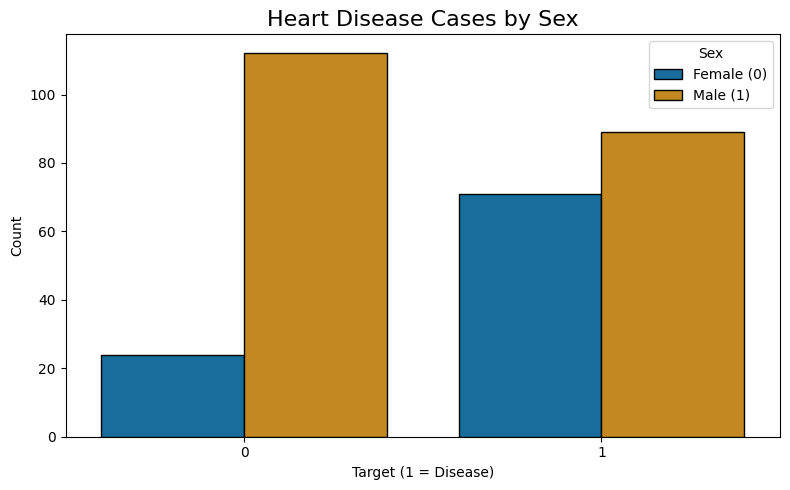

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x="target", 
    hue="sex",
    palette="colorblind",
    edgecolor="black"
)

plt.title("Heart Disease Cases by Sex", fontsize=16)
plt.xlabel("Target (1 = Disease)")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.legend(title="Sex", labels=["Female (0)", "Male (1)"])
plt.tight_layout()
plt.show()

Visually, the number of heart disease cases appears similar for both males and females. However, because there are more male patients overall, the proportion of females with heart disease is actually higher. This explains why the female proportion is greater despite the similar case counts.

Although the dataset could be rebalanced through oversampling or undersampling, we will proceed without it due to the small sample size, focusing on the overall population rather than gender stratification.

#### Distribution of Numerical Features

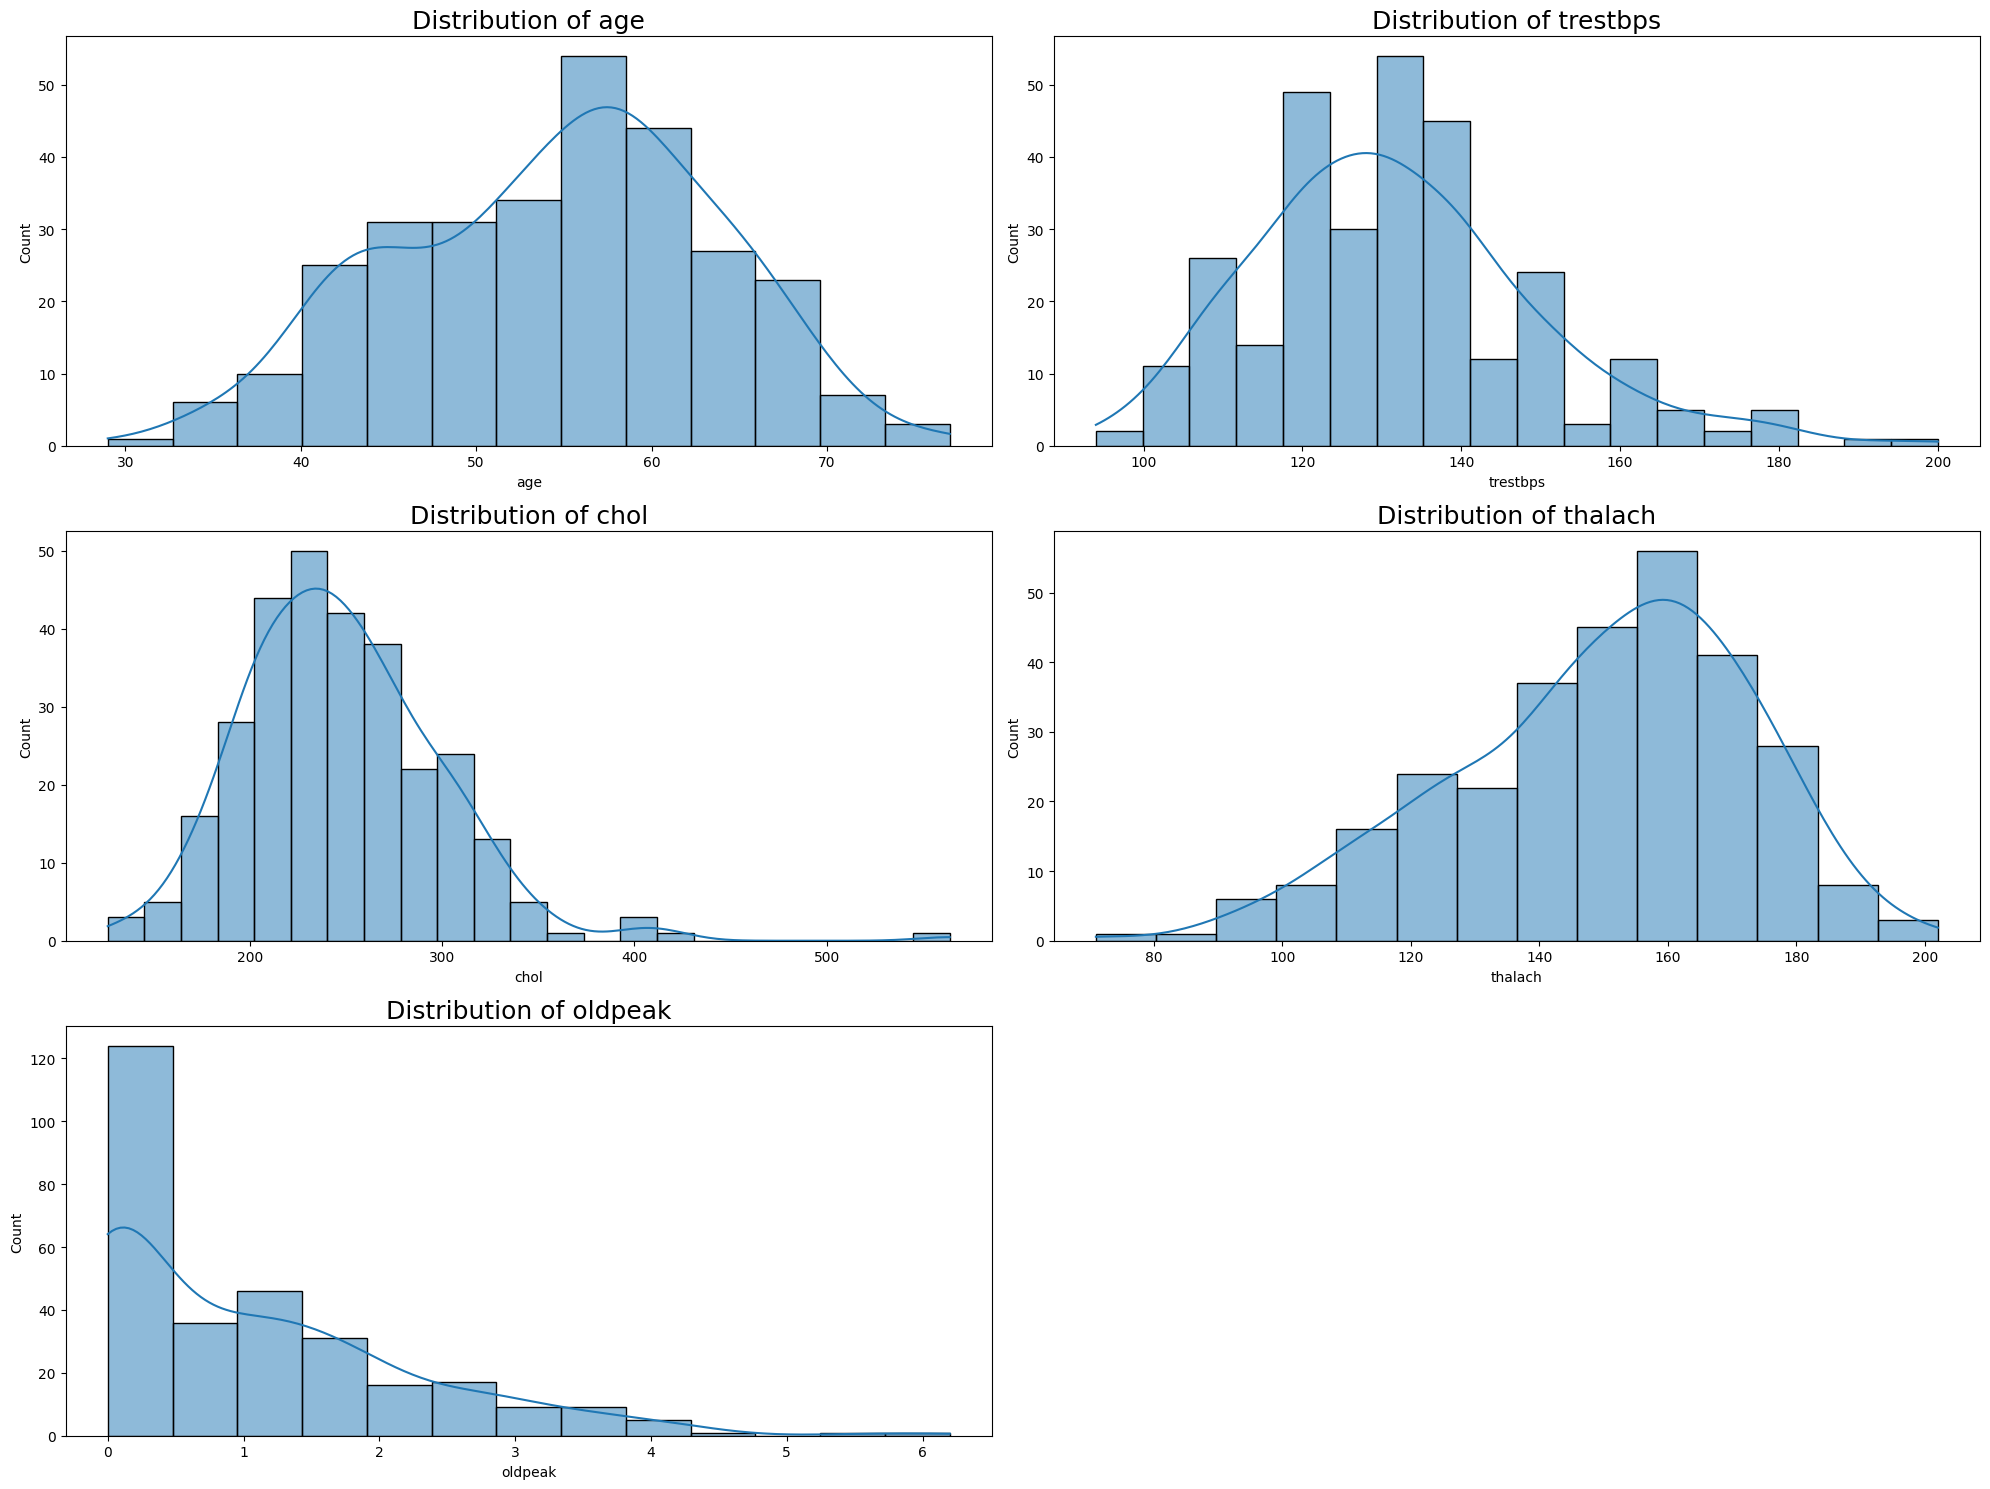

In [14]:
dist_columns=['age','trestbps','chol','thalach','oldpeak']
num_columns = len(dist_columns)
ncols = 2
fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=(20, 15))

for i, column in enumerate(dist_columns):
    row = i // ncols
    col = i % ncols
    sns.histplot(df[column], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {column}',fontsize=18)

# remove unused subplot(s)
for j in range(len(dist_columns), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout() # Adjust the space between charts
plt.show()

#### Correlation Analysis

Let's see now the correlation matrix to identify relevant features for the model.

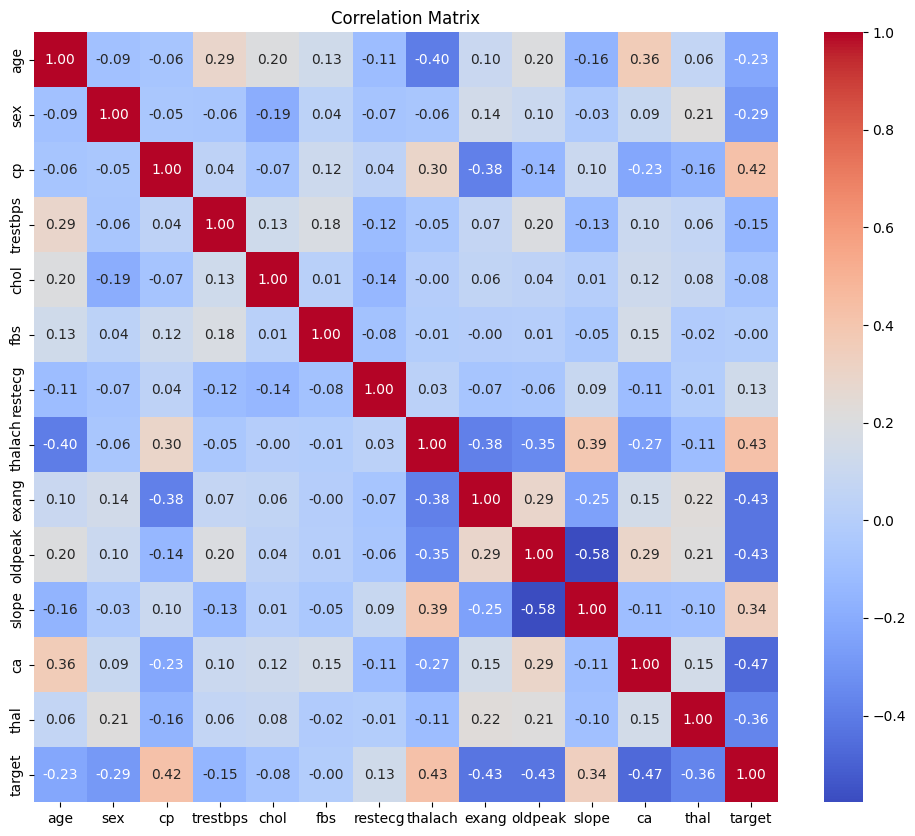

In [15]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- The features that show the highest correlation with the target variable (presence of heart disease) are:
    - 'cp' (chest pain type) with a correlation of approximately 0.42
    - 'thalach' (maximum heart rate achieved) with a correlation of approximately 0.43
    - 'slope' (the slope of the peak exercise ST segment) with a correlation of approximately 0.34
- Slope and thalach show a correlation between them of approximately 0.39.
- Thalach and cp also show a moderate correlation of approximately 0.42.
- Trestbps (resting blood pressure), chol (serum cholesterol), oldpeak (ST depression), and ca (number of major vessels) show moderate correlation with age (0.29, 0.20, 0.20 and 0.36 respectively).
> These features are likely to be the most informative for predicting the presence of heart disease and should be prioritized when selecting features for the classification model.

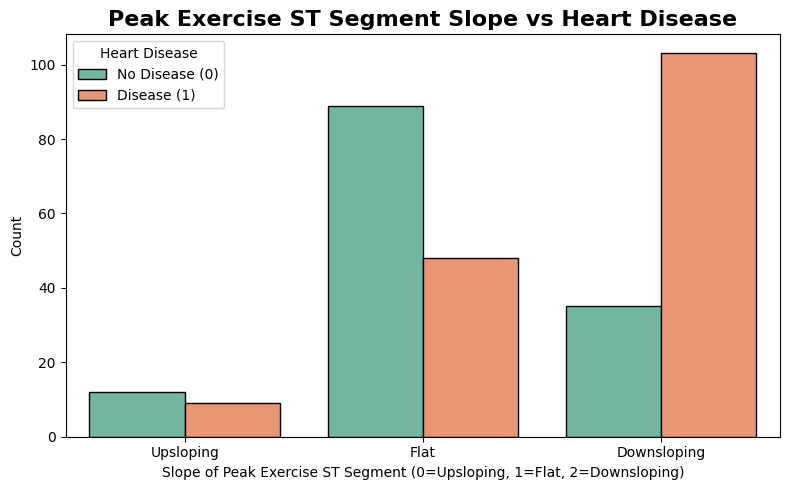

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='slope',
    hue='target',
    palette='Set2',
    edgecolor='black'
)

plt.title("Peak Exercise ST Segment Slope vs Heart Disease", fontsize=16, weight='bold')
plt.xlabel("Slope of Peak Exercise ST Segment (0=Upsloping, 1=Flat, 2=Downsloping)")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease (0)", "Disease (1)"])
plt.xticks([0,1,2], ["Upsloping", "Flat", "Downsloping"])  # better x-axis labels
plt.tight_layout()
plt.show()


Slope indicates the slope of the peak exercise ST segment. A higher slope value is associated with a lower risk of heart disease, while a lower slope value indicates a higher risk. This feature reflects the heart's response to exercise and can provide insights into cardiovascular health.

Slope values:
- 0: Upsloping ST segment (normal response to exercise)
- 1: Flat ST segment (intermediate risk)
- 2: Downsloping ST segment (higher risk of heart disease)

> We can see that patients with a slope value of 2 (downsloping ST segment) have a higher prevalence of heart disease compared to those with slope values of 0 or 1. This suggests that the slope of the peak exercise ST segment is an important feature for predicting heart disease.

#### Encoding

- Categorical features with more than two categories (cp, restecg), we will use one-hot encoding for those features.
- Binary categorical features (sex, fbs, exang, target), we will use label encoding (0 and 1) (already done).
- Numerical features, we will use Standard scaling to normalize them. Thal, slope, ca will be treated as ordinal variables.

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_features = ['sex', 'fbs', 'exang']  # already binary encoded
ordinal_features = ['slope', 'thal', 'ca']
categorical_features = ['cp', 'restecg']

# We use StandardScaler to standardize numerical features
# instead of Min-Max scaling to preserve outliers information
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

one_hot_encoder = OneHotEncoder()
encoded_features = one_hot_encoder.fit_transform(df[categorical_features]).toarray()
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)
df = pd.concat([df.drop(columns=categorical_features), encoded_df], axis=1)

We will focus our correlation analysis on the one-hot encoded categorical features and the target variable.

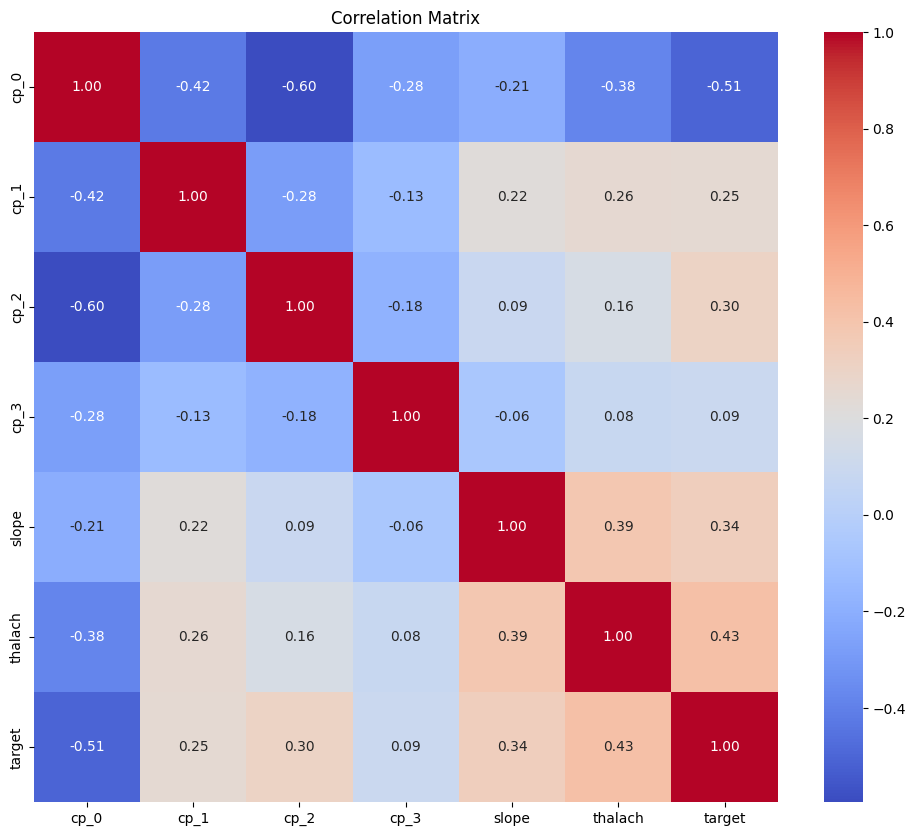

In [18]:
selected_features = [
    'cp_0', 'cp_1', 'cp_2', 'cp_3',
    'slope',
    'thalach',
]
selected_df = df[selected_features + ['target']]
plt.figure(figsize=(12, 10))
correlation_matrix = selected_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- After one-hot encoding cp we can see clearly that cp_1 (atypical angina) and cp_2 (non-anginal pain) have the highest correlation with the target variable (presence of heart disease), with correlations of approximately 0.25 and 0.30. While cp_0 (typical angina) and cp_3 (asymptomatic) show lower correlations of approximately -0.51 and 0.09 as it could be expected.
- Slope and Thalach keep the same correlations as before (0.34 and 0.43 respectively with the target variable).

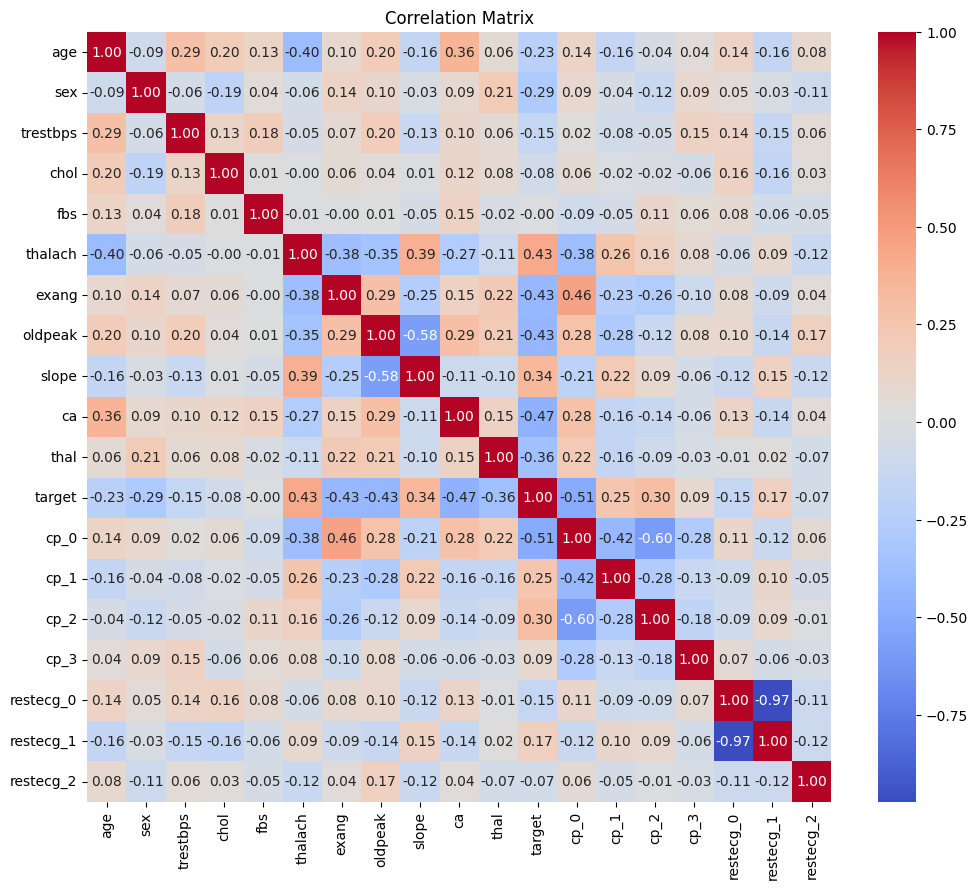

In [19]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Checking the full correlation matrix again, we can see that restecg_1 (having ST-T wave abnormality) has a moderate positive correlation with the target variable (approximately 0.20), while restecg_0 (normal) has a moderate negative correlation (approximately -0.20) and restecg_2 (showing probable or definite left ventricular hypertrophy) has a weak correlation close to zero. This suggests that patients with ST-T wave abnormalities are more likely to have heart disease, while those with normal ECG results are less likely.

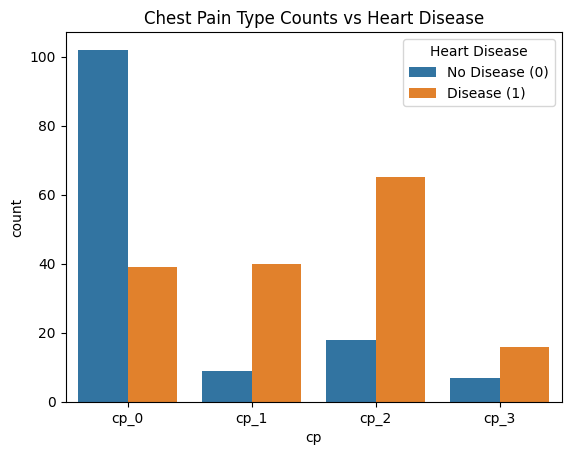

In [20]:
cp_long = df.melt(
    id_vars='target',
    value_vars=['cp_0', 'cp_1', 'cp_2', 'cp_3'],
    var_name='cp',
    value_name='value'
)

cp_long = cp_long[cp_long['value'] == 1]

sns.countplot(data=cp_long, x='cp', hue='target')
plt.title('Chest Pain Type Counts vs Heart Disease')
plt.legend(title="Heart Disease", labels=["No Disease (0)", "Disease (1)"])
plt.show()

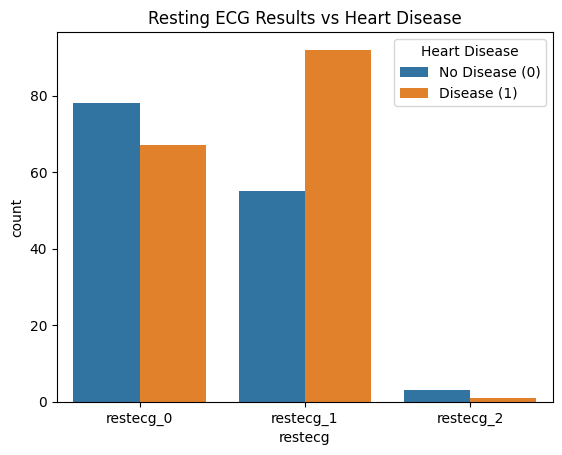

In [21]:
cp_long = df.melt(
    id_vars='target',
    value_vars=['restecg_0', 'restecg_1', 'restecg_2'],
    var_name='restecg',
    value_name='value'
)

cp_long = cp_long[cp_long['value'] == 1]

sns.countplot(data=cp_long, x='restecg', hue='target')
plt.title('Resting ECG Results vs Heart Disease')
plt.legend(title="Heart Disease", labels=["No Disease (0)", "Disease (1)"])
plt.show()

In [22]:
# thal 

Finally, we will create a train-test split for model training and evaluation.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['target']),
    df['target'],
    test_size=0.2,
    random_state=42
)

### Model Training and Evaluation

We will try different classification algorithms for this problem.

#### Tree-based Classifier

Tree-based classifiers are well-suited for this problem due to their ability to handle both numerical and categorical features, as well as their interpretability. They can capture complex relationships in the data and are less sensitive to feature scaling compared to other algorithms.

Accuracy: 73.33 %
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68        24
           1       0.79      0.75      0.77        36

    accuracy                           0.73        60
   macro avg       0.72      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

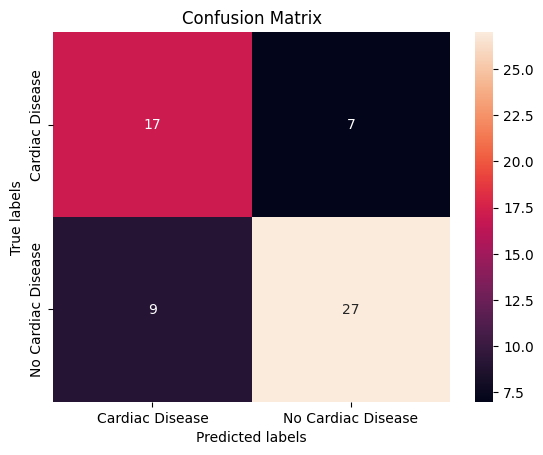

In [24]:
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = tree.DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy_clf = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_clf * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_pred))
# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

![](images/precision_recall.png)

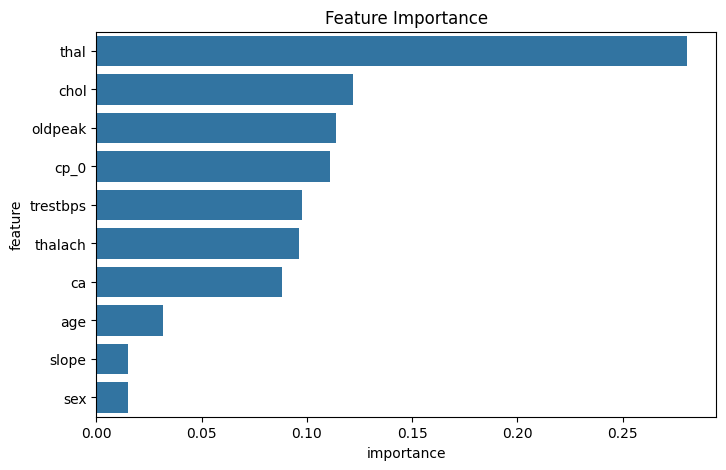

In [25]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

We have an accuracy of 83.33%, with 6 false negatives and 4 false positives.

#### Random Forest Classifier

Random forest improves upon decision trees by reducing overfitting through ensemble learning. It builds multiple decision trees on different subsets of the data and averages their predictions, leading to better generalization and robustness.

Random Forest Accuracy: 86.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        24
           1       0.89      0.89      0.89        36

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

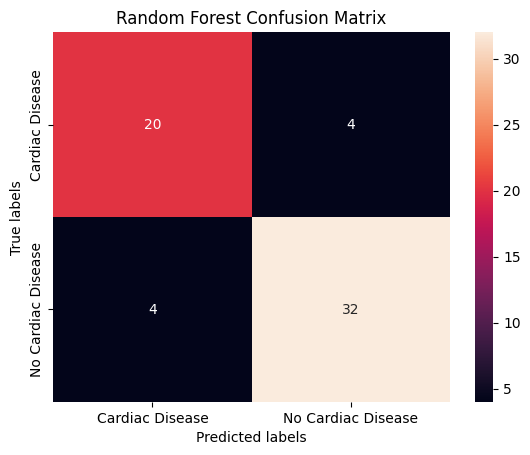

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_rf_pred = rf_clf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_rf_pred)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_rf_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_rf_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("Random Forest Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

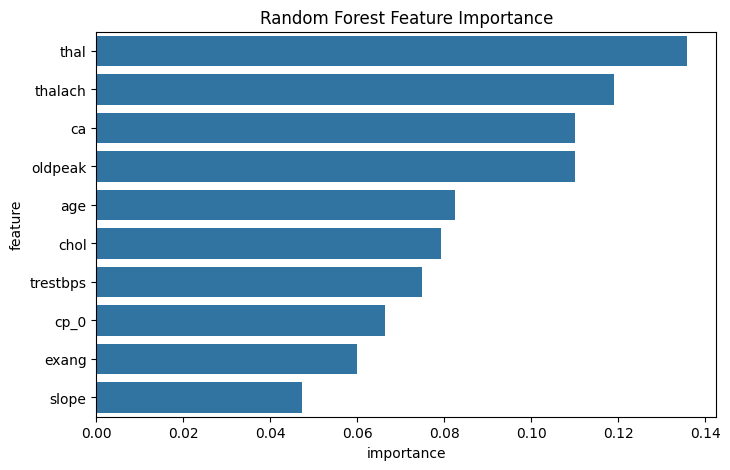

In [27]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Random Forest Feature Importance")
plt.show()

Accuracy: 86.67% vs 73.33% for decision tree.
False Positives: 4 vs 9 for decision tree.
False Negatives: 4 vs 7 for decision tree.

#### SVM Classifier

SVM is a powerful classification algorithm that can handle high-dimensional data and find complex decision boundaries. It is effective for binary classification problems like this one, where we need to distinguish between patients with and without heart disease.

SVM Accuracy: 91.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.92      0.94      0.93        36

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

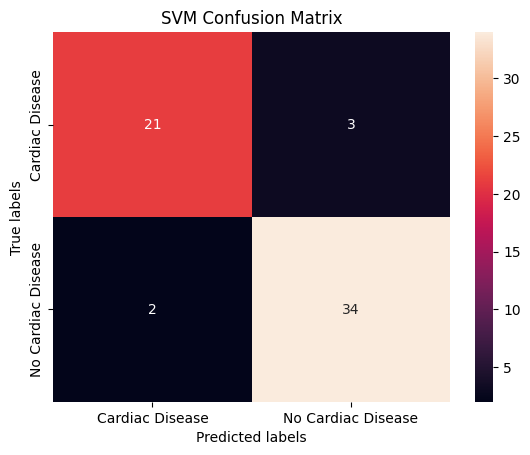

In [28]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='linear', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)
y_svm_pred = svm_clf.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_svm_pred)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_svm_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_svm_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("SVM Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

Accuracy: 91.67% ~ 92%
False Positives: 3
False Negatives: 2

#### k-NN Classifier

kNN is a simple yet effective classification algorithm that can capture local patterns in the data. It is particularly useful when the decision boundary is complex and non-linear. However, it can be sensitive to feature scaling and may not perform well with high-dimensional data.

k-NN Accuracy: 81.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        24
           1       0.88      0.81      0.84        36

    accuracy                           0.82        60
   macro avg       0.81      0.82      0.81        60
weighted avg       0.82      0.82      0.82        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

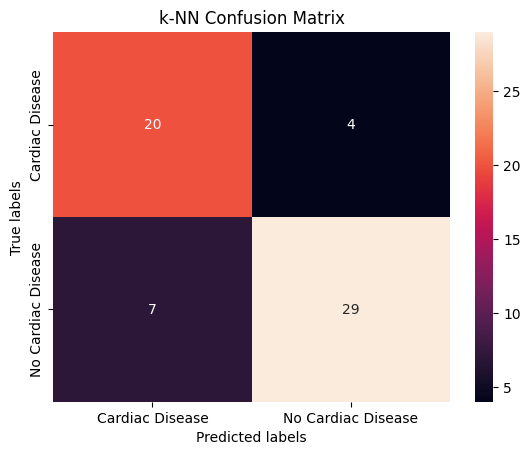

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_knn_pred = knn_clf.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_knn_pred)
print(f"k-NN Accuracy: {accuracy_knn * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_knn_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_knn_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("k-NN Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

kNN achieved an accuracy of 83.33%, with 7 false negatives and 4 false positives.

### Summary of Results

We evaluated four classification algorithms for predicting the presence of heart disease: Decision Tree, Random Forest, SVM, and k-NN.
- Decision Tree achieved an accuracy of 73.33%, with 7 false negatives and 9 false positives.
- Random Forest improved upon the Decision Tree with an accuracy of 86.67%, reducing false negatives to 4 and false positives to 4.
- SVM outperformed all other models with an accuracy of 91.67%, achieving only 2 false negatives and 3 false positives.
- k-NN achieved an accuracy of 83.33%, with 6 false negatives and 4 false positives.

Overall, SVM provided the best performance in terms of accuracy and minimizing false negatives, making it the most suitable choice for this problem.

### Other models tried

#### Random Forest with Probability Calibration

Calibrated Random Forest Accuracy: 86.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        24
           1       0.89      0.89      0.89        36

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



/home/javier/Documents/IA/IA learning/lab2/.venv/lib/python3.13/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

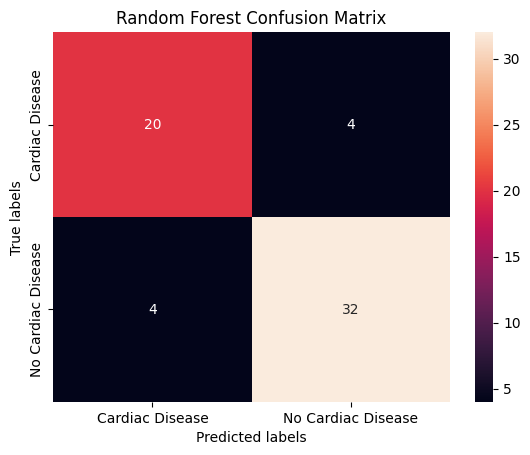

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf_clf = CalibratedClassifierCV(rf_clf, method='sigmoid', cv='prefit')
calibrated_rf_clf.fit(X_train, y_train)
y_calibrated_rf_pred = calibrated_rf_clf.predict(X_test)
    
accuracy_calibrated_rf = accuracy_score(y_test, y_calibrated_rf_pred)
print(f"Calibrated Random Forest Accuracy: {accuracy_calibrated_rf * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_calibrated_rf_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_calibrated_rf_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("Random Forest Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

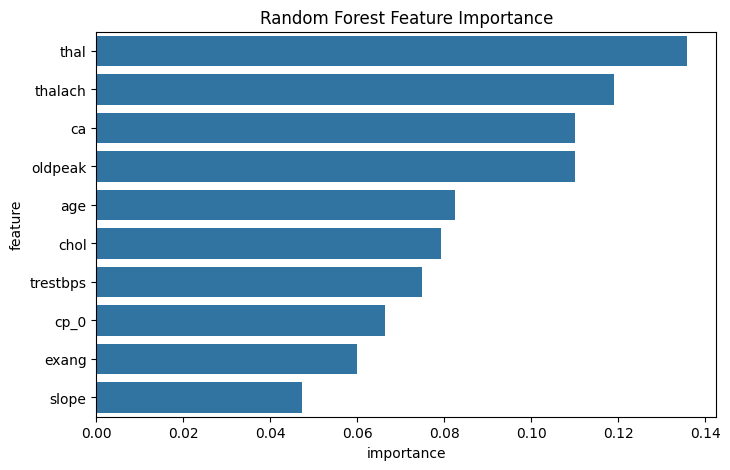

In [31]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': calibrated_rf_clf.estimator.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Random Forest Feature Importance")
plt.show()

Random Forest gives numerical features higher importance because:
- They have more possible split points
- They reduce node impurity more effectively
- RF importance does not directly measure correlation, only impact on the model’s splits.

In [32]:
from sklearn.metrics import brier_score_loss
rf_probs = rf_clf.predict_proba(X_test)[:, 1]
calibrated_probs = calibrated_rf_clf.predict_proba(X_test)[:, 1]

print("RF Brier Score:", brier_score_loss(y_test, rf_probs))
print("Calibrated RF Brier Score:", brier_score_loss(y_test, calibrated_probs))


RF Brier Score: 0.10467333333333334
Calibrated RF Brier Score: 0.10014455681210918


While calibration did not alter classification accuracy, it improved probabilistic predictions as evidenced by a reduction in the Brier score from 0.1043 to 0.0996. This indicates better alignment between predicted probabilities and observed outcomes, which is particularly important for clinical decision-making. But we would still choose SVM as the best model for this problem due to its superior accuracy and lower false negative rate.

#### XGBoost Classifier

XGBoost is an advanced ensemble learning algorithm that builds upon the principles of gradient boosting. It is designed to optimize both speed and performance, making it suitable for large datasets and complex problems. XGBoost incorporates regularization techniques to prevent overfitting, and it can handle missing values and categorical features effectively.

/home/javier/Documents/IA/IA learning/lab2/.venv/lib/python3.13/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


XGBoost Accuracy: 88.33 %
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        24
           1       0.89      0.92      0.90        36

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

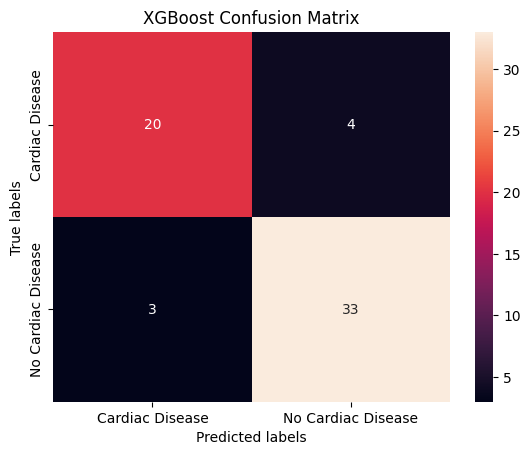

In [33]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)
y_xgb_pred = xgb_clf.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_xgb_pred)
print(f"XGBoost Accuracy: {accuracy_xgb * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_xgb_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_xgb_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("XGBoost Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

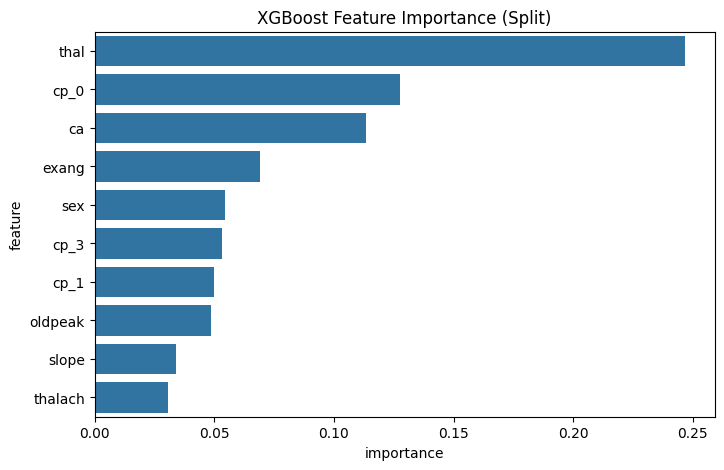

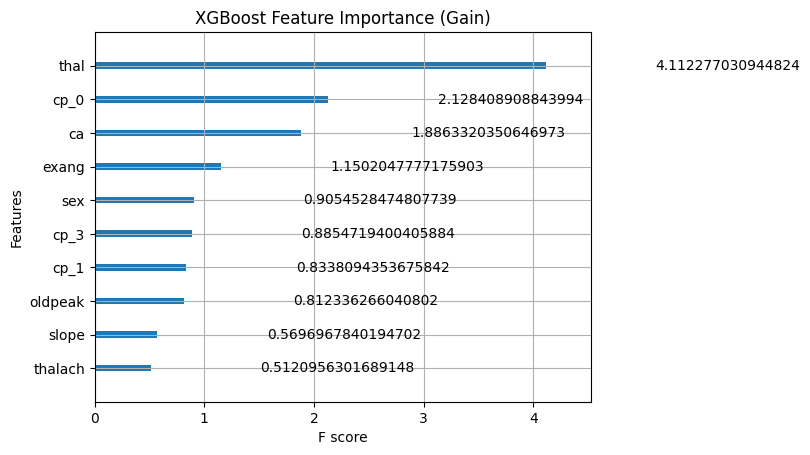

In [34]:
from xgboost import plot_importance

xgb_feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values(by='importance', ascending=False)    
plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_feat_imp.head(10), y='feature', x='importance')
plt.title("XGBoost Feature Importance (Split)")
plt.show()

# Gain-based feature importance for gradient boosting models
plot_importance(xgb_clf, max_num_features=10, importance_type='gain')
plt.title("XGBoost Feature Importance (Gain)")
plt.show()

In [35]:
# from sklearn.model_selection import GridSearchCV

# grid = {
#     'n_estimators': [50, 100, 150],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2]
# }

# grid_search = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
#                            param_grid=grid,
#                            scoring='accuracy',
#                            cv=5,
#                            verbose=1)
# grid_search.fit(X_train, y_train)
# print("Accuracy after Grid Search: ", grid_search.best_score_)
# print("Classification Report after Grid Search:")
# print(classification_report(y_test, grid_search.predict(X_test)))
# print("Best parameters found: ", grid_search.best_params_)
# Output:
# Fitting 5 folds for each of 27 candidates, totalling 135 fits
# Accuracy after Grid Search:  0.7964539007092198
# Classification Report after Grid Search:
#               precision    recall  f1-score   support

#            0       0.79      0.79      0.79        24
#            1       0.86      0.86      0.86        36

#     accuracy                           0.83        60
#    macro avg       0.83      0.83      0.83        60
# weighted avg       0.83      0.83      0.83        60

# Best parameters found:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150}

XGBoost didn't outperform SVM, achieving an accuracy of 88% with 3 false negatives and 4 false positives.
 
Grid search for hyperparameter tuning was attempted but did not lead to significant improvements.

#### LightGBM Classifier

LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be efficient and scalable, making it suitable for large datasets. LightGBM employs techniques such as histogram-based decision tree learning and leaf-wise tree growth to improve training speed and reduce memory usage. It also supports categorical features natively and includes regularization methods to prevent overfitting.

[LightGBM] [Info] Number of positive: 124, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 243
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Accuracy: 91.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.92      0.94      0.93        36

    accuracy                           0.92        60
   macro avg       0.92      0.

[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

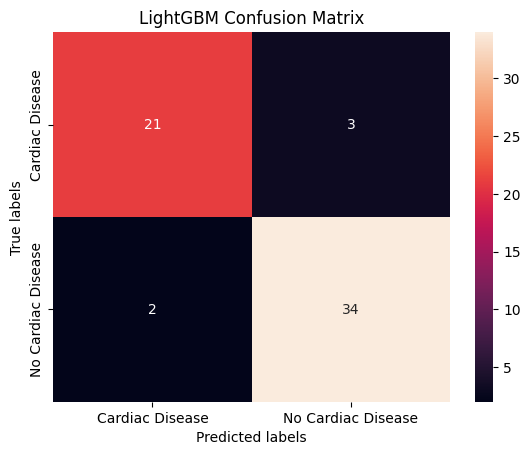

In [36]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(random_state=42, num_leaves=7, n_estimators=100, class_weight="balanced", max_depth=5, verbose=1)
lgbm_clf.fit(X_train, y_train)
y_lgbm_pred = lgbm_clf.predict(X_test)

accuracy_lgbm = accuracy_score(y_test, y_lgbm_pred)
print(f"LightGBM Accuracy: {accuracy_lgbm * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_lgbm_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_lgbm_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("LightGBM Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

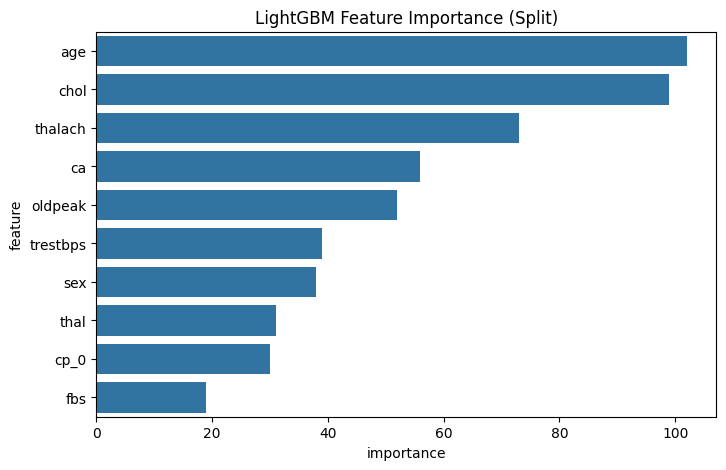

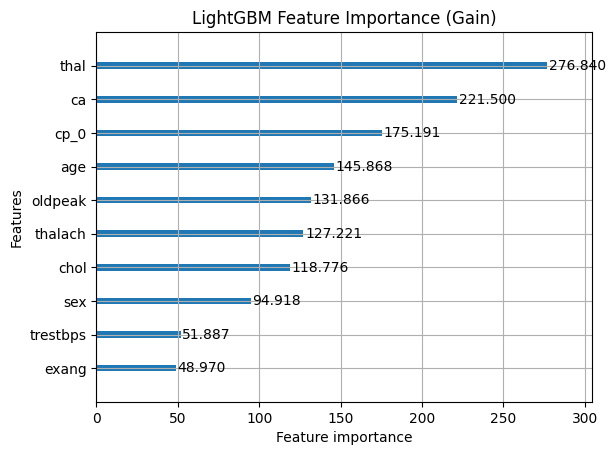

In [37]:
from lightgbm import plot_importance

lgbm_feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values(by='importance', ascending=False)    
plt.figure(figsize=(8, 5))
sns.barplot(data=lgbm_feat_imp.head(10), y='feature', x='importance')
plt.title("LightGBM Feature Importance (Split)")
plt.show()

# Gain-based feature importance for gradient boosting models
plot_importance(lgbm_clf, max_num_features=10, importance_type='gain')
plt.title("LightGBM Feature Importance (Gain)")
plt.show()

In [38]:
# from sklearn.model_selection import GridSearchCV

# param_grid_lgb = {
#     'n_estimators': [100, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'num_leaves': [7]
# }

# grid_lgb = GridSearchCV(estimator=LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1),
#                         param_grid=param_grid_lgb,
#                         scoring='f1',
#                         cv=5,)
# grid_lgb.fit(X_train, y_train)
# best_lgbm_clf = grid_lgb.best_estimator_
# y_best_lgbm_pred = best_lgbm_clf.predict(X_test)
# print(f"Tuned LightGBM Accuracy: {accuracy_score(y_test, y_best_lgbm_pred) * 100:.2f} %")
# print("Classification Report:")
# print(classification_report(y_test, y_best_lgbm_pred))
# print("Best LightGBM Parameters:", best_lgbm_clf.get_params())
# Output:
# Classification Report:
#               precision    recall  f1-score   support

#            0       0.91      0.88      0.89        24
#            1       0.92      0.94      0.93        36

#     accuracy                           0.92        60
#    macro avg       0.92      0.91      0.91        60
# weighted avg       0.92      0.92      0.92        60
# Best LightGBM Parameters: {'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 7, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}


LightGBM managed to achieve similar accuracy to SVM, after hyperparameter tuning using GridSearchCV (commented out in the code to save time during execution).

#### CatBoost Classifier

CatBoost is a gradient boosting algorithm that is particularly effective for handling categorical features. It uses a unique approach called ordered boosting, which helps to reduce overfitting and improve model performance. CatBoost also incorporates techniques such as symmetric tree structures and efficient handling of missing values.

CatBoost Accuracy: 90.00 %
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        24
           1       0.92      0.92      0.92        36

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

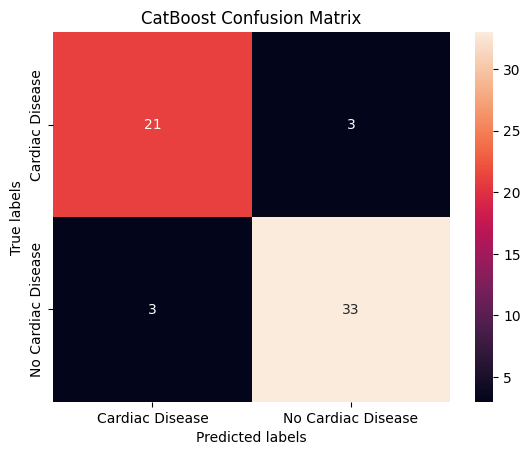

In [39]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(random_state=42, verbose=0, iterations=200, learning_rate=0.01, depth=3, l2_leaf_reg=3)
cat_clf.fit(X_train, y_train)
y_cat_pred = cat_clf.predict(X_test)

accuracy_cat = accuracy_score(y_test, y_cat_pred)
print(f"CatBoost Accuracy: {accuracy_cat * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_cat_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_cat_pred), fmt='g', annot
=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("CatBoost Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

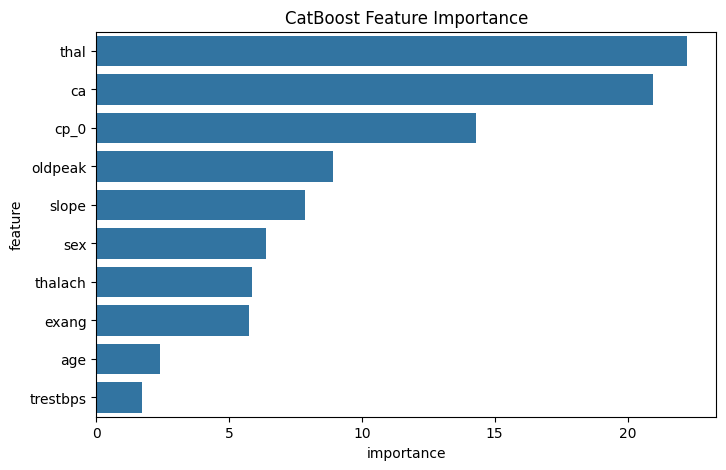

In [40]:
cat_feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_clf.get_feature_importance()
}).sort_values(by='importance', ascending=False)    
plt.figure(figsize=(8, 5))
sns.barplot(data=cat_feat_imp.head(10), y='feature', x='importance')
plt.title("CatBoost Feature Importance")
plt.show()

In [41]:
# from sklearn.model_selection import GridSearchCV

# param_grid_cat = {
#     'iterations': [100, 200],
#     'depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1],
#     'l2_leaf_reg': [1, 3, 5]
# }

# grid_cat = GridSearchCV(estimator=CatBoostClassifier(random_state=42, verbose=0),
#                         param_grid=param_grid_cat,
#                         scoring='f1',
#                         cv=5,)
# grid_cat.fit(X_train, y_train)
# best_cat_clf = grid_cat.best_estimator_
# y_best_cat_pred = best_cat_clf.predict(X_test)
# print(f"Tuned CatBoost Accuracy: {accuracy_score(y_test, y_best_cat_pred) * 100:.2f} %")
# print("Classification Report:")
# print(classification_report(y_test, y_best_cat_pred))
# print("Best CatBoost Parameters:", best_cat_clf.get_params())
# Output:
# Tuned CatBoost Accuracy: 90.00 %
# Classification Report:
#               precision    recall  f1-score   support

#            0       0.88      0.88      0.88        24
#            1       0.92      0.92      0.92        36

#     accuracy                           0.90        60
#    macro avg       0.90      0.90      0.90        60
# weighted avg       0.90      0.90      0.90        60

# Best CatBoost Parameters: {'verbose': 0, 'random_state': 42, 'depth': 3, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.01}

CatBoost did not outperform SVM, achieving an accuracy of 90% with 3 false negatives and 3 false positives.

#### Naive Bayes Classifier

Naive Bayes is a simple yet effective probabilistic classification algorithm based on Bayes' theorem. It assumes that the features are conditionally independent given the class label, which simplifies the computation of probabilities. Naive Bayes is particularly useful for high-dimensional data and can handle both categorical and numerical features.

Naive Bayes Accuracy: 75.00 %
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.42      0.57        24
           1       0.71      0.97      0.82        36

    accuracy                           0.75        60
   macro avg       0.81      0.69      0.70        60
weighted avg       0.79      0.75      0.72        60



[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

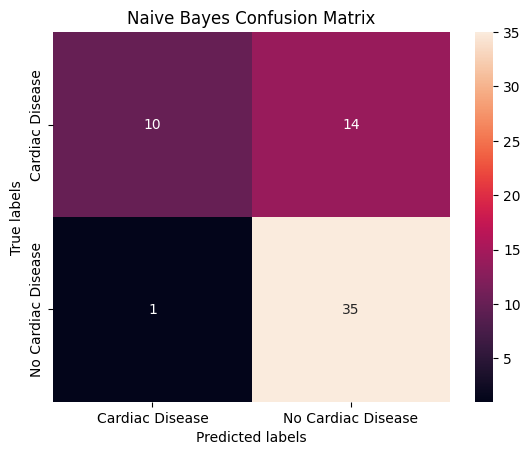

In [42]:
from sklearn.naive_bayes import GaussianNB

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)
y_nb_pred = nb_clf.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_nb_pred)
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_nb_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_nb_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("Naive Bayes Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

Naive Bayes accuracy was lower than other models, achieving 75% with 1 false negatives and 14 false positives.

#### Voting Classifier

Voting Classifier is an ensemble learning method that combines the predictions of multiple base classifiers to improve overall performance. It can use either hard voting (majority class) or soft voting (average predicted probabilities) to make final predictions. This approach leverages the strengths of different algorithms and can lead to better generalization on unseen data.

[LightGBM] [Info] Number of positive: 124, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 243
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Voting Classifier Accuracy: 91.67 %
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.92      0.94      0.93        36

    accuracy                           0.92        60
   macro avg       0.9

[Text(0, 0.5, 'Cardiac Disease'), Text(0, 1.5, 'No Cardiac Disease')]

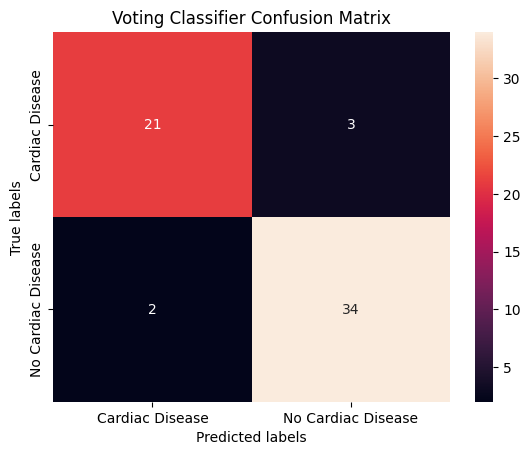

In [43]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('svm', svm_clf),
        ('lgbm', lgbm_clf),
        ('cat', cat_clf),
        # ('xgb', xgb_clf) doesn't work
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
y_voting_pred = voting_clf.predict(X_test)

accuracy_voting = accuracy_score(y_test, y_voting_pred)
print(f"Voting Classifier Accuracy: {accuracy_voting * 100:.2f} %")
print("Classification Report:")
print(classification_report(y_test, y_voting_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_voting_pred), fmt='g', annot=True, ax=ax)
ax.set_xlabel("Predicted labels")
ax.set_ylabel("True labels")
ax.set_title("Voting Classifier Confusion Matrix")
ax.xaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])
ax.yaxis.set_ticklabels(['Cardiac Disease', 'No Cardiac Disease'])

Voting Classifier achieved an accuracy of 92%, with 2 false negatives and 3 false positives, similar to SVM and LightGBM. And CatBoost which had 3 false negatives and 3 false positives and accuracy of 90%.

### Comparison of Models

Our winner model was SVM, achieving an accuracy of approximately 92% with only 2 false negatives and 3 false positives. But now we have two more models that have achieved similar performance: LightGBM and Voting Classifier. Let's compare them all visually.

#### Accuracy Comparison

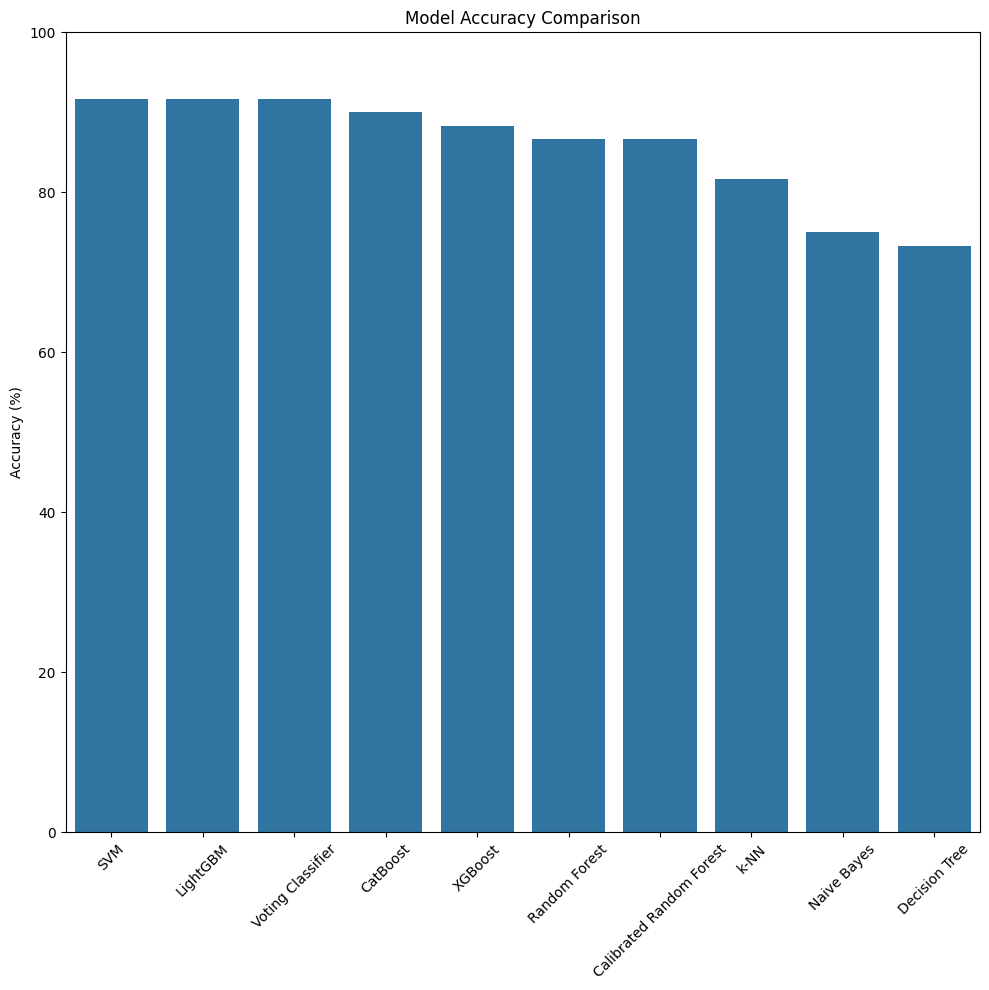

In [50]:
models = ['Decision Tree', 'Random Forest', 'SVM', 'k-NN', 'Calibrated Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Naive Bayes', 'Voting Classifier']
accuracies = [
    accuracy_clf,
    accuracy_rf,
    accuracy_svm,
    accuracy_knn,
    accuracy_calibrated_rf,
    accuracy_xgb,
    accuracy_lgbm,
    accuracy_cat,
    accuracy_nb,
    accuracy_voting,
]
models, accuracies = zip(*sorted(zip(models, accuracies), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(10, 10))
sns.barplot(x=models, y=[acc * 100 for acc in accuracies])
plt.xticks(rotation=45)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### AOC Curves Comparison

<Figure size 1000x800 with 0 Axes>

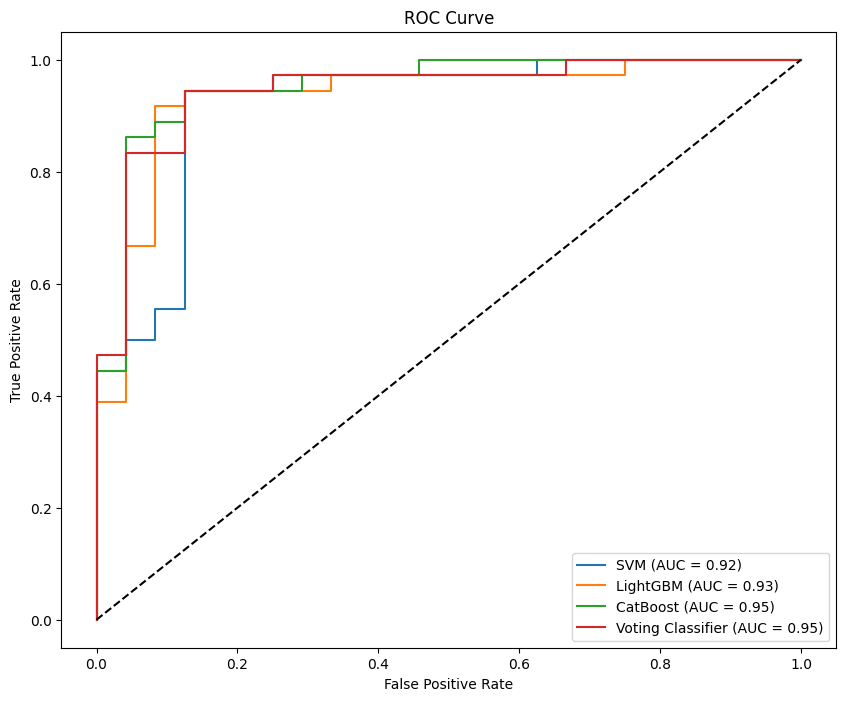

In [45]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
model_probs = {
    'SVM': svm_clf.predict_proba(X_test)[:, 1],
    'LightGBM': lgbm_clf.predict_proba(X_test)[:, 1],
    'CatBoost': cat_clf.predict_proba(X_test)[:, 1],
    'Voting Classifier': voting_clf.predict_proba(X_test)[:, 1],
}

plt.figure(figsize=(10, 8))
for model_name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.step(fpr, tpr, where='post', label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Looking at the accuracies of the different models and the ROC curves, we can see that CatBoost is the best performing model for this problem, achieving the highest accuracy and AUC value.
> Voting Classifier is close second in performance, followed by LightGBM and SVM.

#### Precision-Recall Comparison

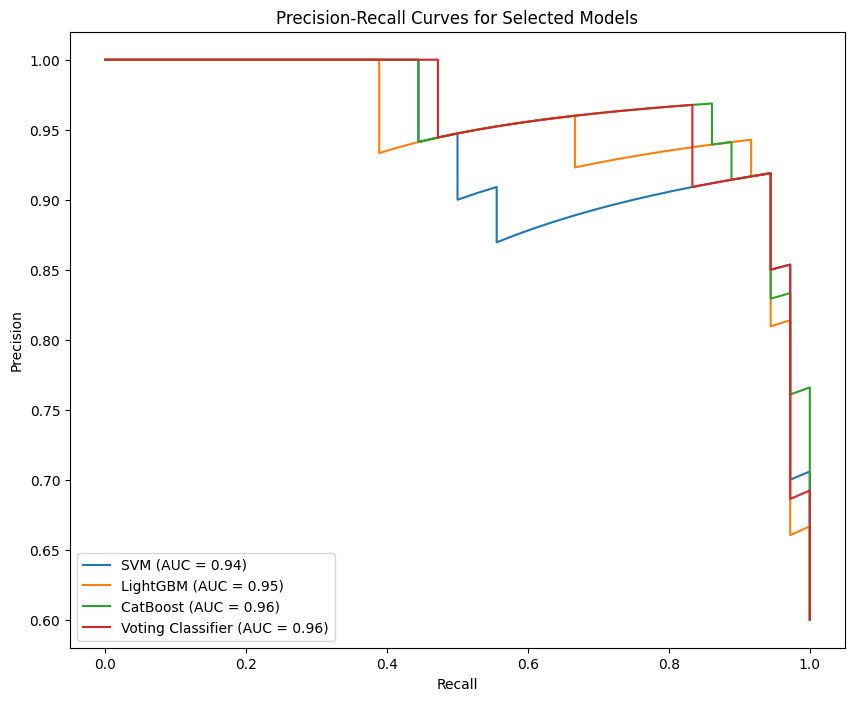

In [46]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(10, 8))

model_probs = {
    'SVM': svm_clf.predict_proba(X_test)[:, 1],
    'LightGBM': lgbm_clf.predict_proba(X_test)[:, 1],
    'CatBoost': cat_clf.predict_proba(X_test)[:, 1],
    'Voting Classifier': voting_clf.predict_proba(X_test)[:, 1],
}

for model_name, probs in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)  # Area under the PR curve
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Selected Models')
plt.legend()
plt.show()


Looking at the precision-recall curves, we can see that CatBoost has the best trade-off between precision and recall, achieving high values for both metrics across different thresholds. This indicates that CatBoost is effective at identifying true positives while minimizing false positives, making it a strong choice for this classification problem.
> Voting Classifier is close second in performance, followed by LightGBM and SVM.

### Final Conclusion

CatBoost is the best performing model for this problem, achieving the highest accuracy and AUC value, as well as the best trade-off between precision and recall. This indicates that CatBoost is effective at identifying true positives while minimizing false positives, making it a strong choice for this classification problem.